# Aprendizado por Reforço

---

**Professor:** Prof. Gabriel Lima  
**Aula:** 06  
**Exercício:** 6B  

---

### Objetivo :  
Implementar para o ambiente da biblioteca gymnasium o algoritmo: 

- DQN

## Bibliotecas Utilizadas

Para a implementação dos algoritmos utilizaremos as seguintes bibliotecas: 

In [1]:
import torch
import numpy as np
import torch.nn as nn
import gymnasium
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd

## Variáveis Importantes

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
seed = 2024
np.random.seed(seed)
np.random.default_rng(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Replay Memory

In [4]:
class ReplayMemory:

    def __init__(self, capacity):

        self.capacity = capacity

        self.states       = deque(maxlen=capacity)
        self.actions      = deque(maxlen=capacity)
        self.next_states  = deque(maxlen=capacity)
        self.rewards      = deque(maxlen=capacity)
        self.dones        = deque(maxlen=capacity)


    def store(self, state, action, next_state, reward, done):

        self.states.append(state)
        self.actions.append(action)
        self.next_states.append(next_state)
        self.rewards.append(reward)
        self.dones.append(done)


    def sample(self, batch_size):

        indices = np.random.choice(len(self), size=batch_size, replace=False)

        states = torch.stack([torch.as_tensor(self.states[i],
        dtype=torch.float32, device=device) for i in indices]).to(device)

        actions = torch.as_tensor([self.actions[i] for i in indices],
                                  dtype=torch.long, device=device)

        next_states = torch.stack([torch.as_tensor(self.next_states[i],
        dtype=torch.float32, device=device) for i in indices]).to(device)

        rewards = torch.as_tensor([self.rewards[i] for i in indices],
                                  dtype=torch.float32, device=device)

        dones = torch.as_tensor([self.dones[i] for i in indices],
                                dtype=torch.bool, device=device)

        return states, actions, next_states, rewards, dones

    def __len__(self):
        return len(self.dones)

## DQN Network

In [5]:
class DQN_Network(nn.Module):

    def __init__(self, num_actions, input_dim):

        super(DQN_Network, self).__init__()

        self.FC = nn.Sequential(
            nn.Linear(input_dim, 12),
            nn.ReLU(inplace=True),
            nn.Linear(12, 8),
            nn.ReLU(inplace=True),
            nn.Linear(8, num_actions)
            )

        #inicialização dos pesos da RNA
        for layer in [self.FC]:
            for module in layer:
                if isinstance(module, nn.Linear):
                    nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')

    def forward(self, x):
        Q = self.FC(x)
        return Q

## Wrappers

In [6]:
class observation_wrapper(gymnasium.ObservationWrapper):

    def __init__(self, env):
        super().__init__(env)

        self.min_value = env.observation_space.low
        self.max_value = env.observation_space.high

    def observation(self, state):
        normalized_state =\
       (state - self.min_value) / (self.max_value - self.min_value)
        return normalized_state

In [7]:
class reward_wrapper(gymnasium.RewardWrapper):
    def __init__(self, env):
        super().__init__(env)


    def reward(self, state):
        current_position, current_velocity = state

        current_velocity = np.interp(current_velocity, np.array([0, 1]),
                                     np.array([-0.5, 0.5]))

        degree = current_position * 360
        degree2radian = np.deg2rad(degree)
        modified_reward =  0.2 * (np.cos(degree2radian) +\
                                  2 * np.abs(current_velocity))

        modified_reward -= 0.5

        if current_position > 0.98:
            modified_reward += 20
        elif current_position > 0.92:
            modified_reward += 10
        elif current_position > 0.82:
            modified_reward += 6
        elif current_position > 0.65:
            modified_reward += 1 - np.exp(-2 * current_position)

        initial_position = 0.40842572

        if current_velocity > 0.3 and current_position > initial_position + 0.1:
            modified_reward += 1 + 2 * current_position

        return modified_reward

In [8]:
class step_wrapper(gymnasium.Wrapper):

    def __init__(self, env):

        super().__init__(env)

        self.observation_wrapper = observation_wrapper(env)
        self.reward_wrapper = reward_wrapper(env)


    def step(self, action):

        state, reward, done, truncation, info = self.env.step(action)

        modified_state = self.observation_wrapper.observation(state)
        modified_reward = self.reward_wrapper.reward(modified_state)

        return modified_state, modified_reward, done, truncation, info


    def reset(self, seed):
        state, info = self.env.reset(seed=seed)
        modified_state = self.observation_wrapper.observation(state)

        return modified_state, info

## Agente DQN 

In [9]:
class DQN_Agent:

    def __init__(self, env, epsilon_max, epsilon_min, epsilon_decay,
                  clip_grad_norm, learning_rate, discount, memory_capacity):

        self.loss_history = []
        self.running_loss = 0
        self.learned_counts = 0

        self.epsilon_max   = epsilon_max
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.discount      = discount

        self.action_space  = env.action_space
        self.action_space.seed(seed)
        self.observation_space = env.observation_space
        self.replay_memory = ReplayMemory(memory_capacity)

        input_dim = self.observation_space.shape[0]
        output_dim = self.action_space.n

        self.main_network = DQN_Network(num_actions=output_dim,
                                        input_dim=input_dim).to(device)

        self.target_network = DQN_Network(num_actions=output_dim,
                                          input_dim=input_dim).to(device).eval()
        

        #copia os pesos main -> target 
        self.target_network.load_state_dict(self.main_network.state_dict())

        self.clip_grad_norm = clip_grad_norm
        self.critertion = nn.MSELoss()
        self.optimizer = optim.Adam(self.main_network.parameters(),
                                    lr=learning_rate)

    def select_action(self, state):

        if np.random.random() < self.epsilon_max:
            return self.action_space.sample()

        if not torch.is_tensor(state):
            state = torch.as_tensor(state, dtype=torch.float32, device=device)

        with torch.no_grad():
            Q_values = self.main_network(state)
            action = torch.argmax(Q_values).item()

            return action


    def learn(self, batch_size, done):

        states, actions, next_states, rewards, dones =\
        self.replay_memory.sample(batch_size)

        actions       = actions.unsqueeze(1)
        rewards       = rewards.unsqueeze(1)
        dones         = dones.unsqueeze(1)

        #feed forward
        predicted_q = self.main_network(states)
        predicted_q = predicted_q.gather(dim=1, index=actions)
        with torch.no_grad():
            next_target_q_value = self.target_network(next_states).\
            max(dim=1, keepdim=True)[0]


        next_target_q_value[dones] = 0
        y_js = rewards + (self.discount * next_target_q_value)
        loss = self.critertion(predicted_q, y_js)

        self.running_loss += loss.item()
        self.learned_counts += 1

        if done:
            episode_loss = self.running_loss / self.learned_counts
            self.loss_history.append(episode_loss)
            self.running_loss = 0
            self.learned_counts = 0

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.main_network.parameters(),
                                       self.clip_grad_norm)

        self.optimizer.step()


    def hard_update(self):
        # main -> target
        self.target_network.load_state_dict(self.main_network.state_dict())


    def update_epsilon(self):
        self.epsilon_max = max(self.epsilon_min,
                               self.epsilon_max * self.epsilon_decay)

## Definição do Ambiente

Considere o seguinte ambiente a ser implementado: 

**Descrição:**

O MDP Mountain car é um MDP deterministico que consiste em um carro situado no fundo de um vale,  
onde possíveis ações de aceleração podem ser aplicadas em duas direções do carro.  
O objetivo é acelerar o carro até o mesmo atingir o topo da montanha.

**Espaço de estados:**  

| Num | Observation                          | Min    | Max    | Unit         |
|-----|--------------------------------------|--------|--------|--------------|
| 0   | position of the car along the x-axis | -1.2   | 0.6    | position (m) |
| 1   | velocity of the car                  | -0.07  | 0.07   | velocity (v) |

**Espaço de ações:**  

0: Acelerar para a esquerda
1: Não acelerar
2: Acelerar para a direita

**Dinâmica de Transição:**  

$ v_{t+1} = v_t + (action - 1) \cdot \text{force} - \cos(3 \cdot x_t) \cdot \text{gravity}$

$x_{t+1} = x_t + v_{t+1}$


**Recompensas:**

O objetivo é atingir o topo da montanha (bandeira amarela) o mais rápido possível, onde o agente é penalizado com recompensa -1 a cada timestep.


**Estado Inicial:**

A posição inicial do carro é um valor que segue uma distribuição aleatória uniforme entre [-0.6,-0.4]. A velocidade é sempre 0.

![GIF](https://gymnasium.farama.org/_images/mountain_car.gif)

### Instanciando o Ambiente

In [10]:
env = gymnasium.make('MountainCar-v0')

### Instanciando o Wrapper

In [11]:
env = step_wrapper(env)

### Instanciando o Agente

In [12]:
Agent = DQN_Agent(env               = env,
                  epsilon_max       = 0.999,
                  epsilon_min       = 0.01,
                  epsilon_decay     = 0.997,
                  clip_grad_norm    = 5,
                  learning_rate     = 75e-5,
                  discount          = 0.96,
                  memory_capacity   = 125000)


## Treino

In [13]:
total_steps = 0
reward_history = []
max_episodes = 1000
update_frequency = 20
batch_size =64

for episode in range(max_episodes):
    state, _ = env.reset(seed=seed)
    done = False
    truncation = False
    step_size = 0
    episode_reward = 0

    while not done and not truncation:
        action = Agent.select_action(state)
        next_state, reward, done, truncation, _ = env.step(action)

        Agent.replay_memory.store(state, action, next_state, reward, done)

        if len(Agent.replay_memory) > batch_size:
            Agent.learn(batch_size, (done or truncation))

            if total_steps % update_frequency == 0:
                Agent.hard_update()

        state = next_state
        episode_reward += reward
        step_size +=1

    reward_history.append(episode_reward)
    total_steps += step_size

    Agent.update_epsilon()

    result = (f"Episode: {episode}, "
              f"Total Steps: {total_steps}, "
              f"Ep Step: {step_size}, "
              f"Raw Reward: {episode_reward:.2f}, "
              f"Epsilon: {Agent.epsilon_max:.2f}")
    print(result)

Episode: 0, Total Steps: 200, Ep Step: 200, Raw Reward: -121.35, Epsilon: 1.00
Episode: 1, Total Steps: 400, Ep Step: 200, Raw Reward: -118.05, Epsilon: 0.99
Episode: 2, Total Steps: 600, Ep Step: 200, Raw Reward: -123.61, Epsilon: 0.99
Episode: 3, Total Steps: 800, Ep Step: 200, Raw Reward: -124.11, Epsilon: 0.99
Episode: 4, Total Steps: 1000, Ep Step: 200, Raw Reward: -125.10, Epsilon: 0.98
Episode: 5, Total Steps: 1200, Ep Step: 200, Raw Reward: -125.05, Epsilon: 0.98
Episode: 6, Total Steps: 1400, Ep Step: 200, Raw Reward: -124.76, Epsilon: 0.98
Episode: 7, Total Steps: 1600, Ep Step: 200, Raw Reward: -126.04, Epsilon: 0.98
Episode: 8, Total Steps: 1800, Ep Step: 200, Raw Reward: -122.82, Epsilon: 0.97
Episode: 9, Total Steps: 2000, Ep Step: 200, Raw Reward: -125.00, Epsilon: 0.97
Episode: 10, Total Steps: 2200, Ep Step: 200, Raw Reward: -120.70, Epsilon: 0.97
Episode: 11, Total Steps: 2400, Ep Step: 200, Raw Reward: -124.39, Epsilon: 0.96
Episode: 12, Total Steps: 2600, Ep Step: 2

## Visualização

In [14]:
def plotMeanRewardOverTime(metadata, slide_window=10):

    # Plot the episode reward over time
    plt.figure(figsize=(6,2))
    rewards_smoothed = pd.Series(metadata).rolling(slide_window,
                                   min_periods=slide_window).mean()
    plt.plot(rewards_smoothed)
    plt.xlabel("Episodio")
    plt.ylabel("Recompensa media")
    plt.title(f"Media Movel de Recompensas")
    plt.show()

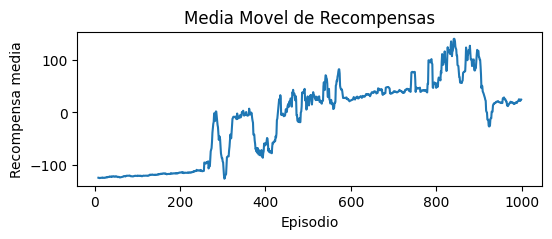

In [15]:
plotMeanRewardOverTime(reward_history)